## Lesson 3

In [1]:
import numpy as np
import pandas as pd

In [2]:
df_OR = pd.read_excel('Online_Retail.xlsx')
df_OR.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df_OR.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.head

<bound method NDFrame.head of                method  number  orbital_period   mass  distance  year
0     Radial Velocity       1      269.300000   7.10     77.40  2006
1     Radial Velocity       1      874.774000   2.21     56.95  2008
2     Radial Velocity       1      763.000000   2.60     19.84  2011
3     Radial Velocity       1      326.030000  19.40    110.62  2007
4     Radial Velocity       1      516.220000  10.50    119.47  2009
...               ...     ...             ...    ...       ...   ...
1030          Transit       1        3.941507    NaN    172.00  2006
1031          Transit       1        2.615864    NaN    148.00  2007
1032          Transit       1        3.191524    NaN    174.00  2007
1033          Transit       1        4.125083    NaN    293.00  2008
1034          Transit       1        4.187757    NaN    260.00  2008

[1035 rows x 6 columns]>

In [5]:
planets['number'].sum()

np.int64(1848)

In [6]:
planets['orbital_period'].mean()

np.float64(2002.9175960947582)

In [7]:
len(planets['method'].unique())

10

In [8]:
planets['method'].isnull().sum()

np.int64(0)

In [9]:
planets['method'].value_counts()

method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

In [10]:
planets.describe()

,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


In [11]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [12]:
planets['number'].value_counts()

number
1    595
2    259
3     88
4     32
5     30
6     24
7      7
Name: count, dtype: int64

In [20]:
def group_method(planets):
    group_df={}
    group_df['Method'] = planets['method'].unique()
    group_df['Total'] = []
    for m in group_df['Method']:
        group_df['Total'].append(planets[planets['method']==m]['number'].sum())
    return pd.DataFrame(group_df)
    

In [21]:
group_method(planets)

,Method,Total
0,Radial Velocity,952
1,Imaging,50
2,Eclipse Timing Variations,15
3,Transit,776
4,Astrometry,2
5,Transit Timing Variations,9
6,Orbital Brightness Modulation,5
7,Microlensing,27
8,Pulsar Timing,11
9,Pulsation Timing Variations,1


In [33]:
df = pd.DataFrame({'key': list("ABCABC"),
                   "data":range(6)},
                   columns=['key','data'])
df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


In [25]:
list(df.groupby('key'))

[('A',
    key  data
  0   A     0
  3   A     3),
 ('B',
    key  data
  1   B     1
  4   B     4),
 ('C',
    key  data
  2   C     2
  5   C     5)]

In [26]:
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


In [27]:
planets[['method','number']].groupby('method').sum()

,number
method,
Astrometry,2
Eclipse Timing Variations,15
Imaging,50
Microlensing,27
Orbital Brightness Modulation,5
Pulsar Timing,11
Pulsation Timing Variations,1
Radial Velocity,952
Transit,776


In [28]:
%timeit planets[['method','number']].groupby('method').sum()
%timeit group_method(planets)

1.13 ms ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.42 ms ± 241 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [30]:
planets[['method','number']].groupby('method').sum().info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Astrometry to Transit Timing Variations
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   number  10 non-null     int64
dtypes: int64(1)
memory usage: 160.0+ bytes


In [31]:
group_method(planets).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Method  10 non-null     object
 1   Total   10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [35]:
df1 = pd.DataFrame({'key': list("ABCABC"),
                   "data1":range(6),
                   'data2':range(6,12)},
                   columns=['key','data1','data2'])
df1 

,key,data1,data2
0,A,0,6
1,B,1,7
2,C,2,8
3,A,3,9
4,B,4,10
5,C,5,11


In [36]:
df1.groupby('key').aggregate('min')

,data1,data2
key,,
A,0,6
B,1,7
C,2,8


In [37]:
df1.groupby('key').aggregate(['min','sum'])

data1     data2    
      min sum   min sum
key                    
A       0   3     6  15
B       1   5     7  17
C       2   7     8  19

In [38]:
def myfunc(x):
    return x.sum()//2
df1.groupby('key').aggregate([myfunc,'sum'])

data1      data2    
    myfunc sum myfunc sum
key                      
A        1   3      7  15
B        2   5      8  17
C        3   7      9  19

In [40]:
df1.groupby('key').aggregate({'data1':['sum', myfunc],'data2':'mean'})

data1        data2
      sum myfunc  mean
key                   
A       3      1   7.5
B       5      2   8.5
C       7      3   9.5

In [41]:
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


In [42]:
df 

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


In [43]:
list(df.groupby('key'))

[('A',
    key  data
  0   A     0
  3   A     3),
 ('B',
    key  data
  1   B     1
  4   B     4),
 ('C',
    key  data
  2   C     2
  5   C     5)]

In [45]:
df.groupby('key').filter(lambda x: x['data'].sum()>=5)

,key,data
1,B,1
2,C,2
4,B,4
5,C,5


In [46]:
df1

,key,data1,data2
0,A,0,6
1,B,1,7
2,C,2,8
3,A,3,9
4,B,4,10
5,C,5,11


In [47]:
list(df1.groupby('key'))

[('A',
    key  data1  data2
  0   A      0      6
  3   A      3      9),
 ('B',
    key  data1  data2
  1   B      1      7
  4   B      4     10),
 ('C',
    key  data1  data2
  2   C      2      8
  5   C      5     11)]

In [48]:
df1.groupby('key').filter(lambda x: x['data2'].mean()>8)

,key,data1,data2
1,B,1,7
2,C,2,8
4,B,4,10
5,C,5,11


In [49]:
list(df.groupby('key'))

[('A',
    key  data
  0   A     0
  3   A     3),
 ('B',
    key  data
  1   B     1
  4   B     4),
 ('C',
    key  data
  2   C     2
  5   C     5)]

In [50]:
df.groupby('key').transform(lambda x: x-x.mean())

,data
0,-1.5
1,-1.5
2,-1.5
3,1.5
4,1.5
5,1.5


In [51]:
df.groupby('key').transform(lambda x: x-x.min())

,data
0,0
1,0
2,0
3,3
4,3
5,3


In [52]:
planets.groupby('method').filter(lambda x: x['number'].sum()>20)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


In [53]:
pd.MultiIndex.from_tuples([('a',1),('a',2),('b',1),('b',3),('c',1)])

MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 3),
            ('c', 1)],
           )

In [54]:
data = {'Country': ['USA', 'USA', 'Canada', 'Canada'],
        'State': ['California', 'New York', 'Ontario', 'Quebec'],
        'City': ['Los Angeles', 'New York City', 'Toronto', 'Montreal'],
        'Population': [3970000, 8419000, 2731000, 1705000]
}
df2 = pd.DataFrame(data)
df2 


,Country,State,City,Population
0,USA,California,Los Angeles,3970000
1,USA,New York,New York City,8419000
2,Canada,Ontario,Toronto,2731000
3,Canada,Quebec,Montreal,1705000


In [56]:
df_multi_index = df2.set_index(['Country', 'State'])
df_multi_index

City  Population
Country State                                
USA     California    Los Angeles     3970000
        New York    New York City     8419000
Canada  Ontario           Toronto     2731000
        Quebec           Montreal     1705000

In [57]:
df_multi_index.index

MultiIndex([(   'USA', 'California'),
            (   'USA',   'New York'),
            ('Canada',    'Ontario'),
            ('Canada',     'Quebec')],
           names=['Country', 'State'])

In [59]:
index = [('California', 2000), ('California', 2010),
         ('New York', 2000), ('New York', 2010),
         ('Texas', 2000), ('Texas', 2010)]

populations = [33871648, 37253956, 18976457, 19378102, 20851820, 25145561]
under18= [9267089, 9284094, 4687374, 4318033,5906301, 6879014]
ind = pd.MultiIndex.from_tuples(index, names=('states','years'))

df_pop = pd.DataFrame({'popopulation':populations, 'under_18':under18}, index=ind)
df_pop

popopulation  under_18
states     years                        
California 2000       33871648   9267089
           2010       37253956   9284094
New York   2000       18976457   4687374
           2010       19378102   4318033
Texas      2000       20851820   5906301
           2010       25145561   6879014

In [61]:
df_pop.index 

MultiIndex([('California', 2000),
            ('California', 2010),
            (  'New York', 2000),
            (  'New York', 2010),
            (     'Texas', 2000),
            (     'Texas', 2010)],
           names=['states', 'years'])

In [60]:
df_pop.loc['New York']

,popopulation,under_18
years,,
2000,18976457,4687374
2010,19378102,4318033


In [62]:
df_pop.loc[('New York',2010)]

popopulation    19378102
under_18         4318033
Name: (New York, 2010), dtype: int64

In [63]:
df_pop.xs(2000,level='years')

,popopulation,under_18
states,,
California,33871648,9267089
New York,18976457,4687374
Texas,20851820,5906301


In [64]:
df_pop

popopulation  under_18
states     years                        
California 2000       33871648   9267089
           2010       37253956   9284094
New York   2000       18976457   4687374
           2010       19378102   4318033
Texas      2000       20851820   5906301
           2010       25145561   6879014

In [65]:
df_pop.stack()

states      years              
California  2000   popopulation    33871648
                   under_18         9267089
            2010   popopulation    37253956
                   under_18         9284094
New York    2000   popopulation    18976457
                   under_18         4687374
            2010   popopulation    19378102
                   under_18         4318033
Texas       2000   popopulation    20851820
                   under_18         5906301
            2010   popopulation    25145561
                   under_18         6879014
dtype: int64

In [66]:
type(df_pop.stack())

pandas.core.series.Series

In [67]:
df_pop

popopulation  under_18
states     years                        
California 2000       33871648   9267089
           2010       37253956   9284094
New York   2000       18976457   4687374
           2010       19378102   4318033
Texas      2000       20851820   5906301
           2010       25145561   6879014

In [68]:
df_pop.unstack()

popopulation           under_18         
years              2000      2010     2000     2010
states                                             
California     33871648  37253956  9267089  9284094
New York       18976457  19378102  4687374  4318033
Texas          20851820  25145561  5906301  6879014

In [69]:
df_pop.unstack().unstack()

              years  states    
popopulation  2000   California    33871648
                     New York      18976457
                     Texas         20851820
              2010   California    37253956
                     New York      19378102
                     Texas         25145561
under_18      2000   California     9267089
                     New York       4687374
                     Texas          5906301
              2010   California     9284094
                     New York       4318033
                     Texas          6879014
dtype: int64

In [70]:
type(df_pop.unstack().unstack())

pandas.core.series.Series

In [71]:
df_pop.unstack().index 

Index(['California', 'New York', 'Texas'], dtype='object', name='states')

In [72]:
df_pop.unstack().columns 

MultiIndex([('popopulation', 2000),
            ('popopulation', 2010),
            (    'under_18', 2000),
            (    'under_18', 2010)],
           names=[None, 'years'])

In [73]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [74]:
titanic[['sex','class','survived']].groupby(['sex','class']).mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22672\2837384371.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic[['sex','class','survived']].groupby(['sex','class']).mean()


survived
sex    class           
female First   0.968085
       Second  0.921053
       Third   0.500000
male   First   0.368852
       Second  0.157407
       Third   0.135447

In [75]:
titanic[['sex','class','survived']].groupby(['sex','class']).mean().unstack()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22672\1685478876.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic[['sex','class','survived']].groupby(['sex','class']).mean().unstack()


survived                    
class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447

In [82]:
pd.pivot_table(data= titanic, 
               index = 'sex',
               columns='class',
               values='survived',
               aggfunc='mean', 
               margins= True,
               margins_name='cus_name')

C:\Users\Admin\AppData\Local\Temp\ipykernel_22672\241520624.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data= titanic,


class,First,Second,Third,cus_name
sex,,,,
female,0.968085,0.921053,0.500000,0.742038
male,0.368852,0.157407,0.135447,0.188908
cus_name,0.629630,0.472826,0.242363,0.383838


<Axes: ylabel='Frequency'>

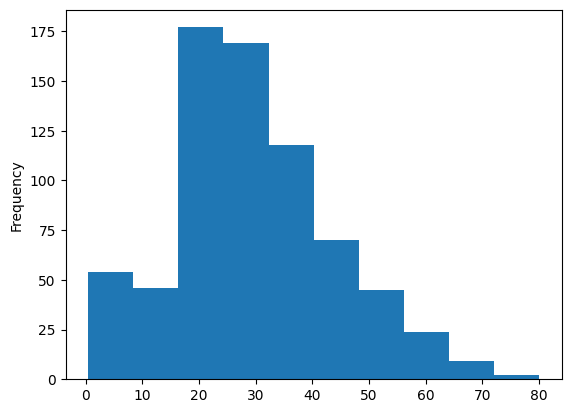

In [83]:
titanic['age'].plot(kind='hist')

In [84]:
pd.qcut(titanic['age'], q=4, labels=['label1','label2','label3','label4'])

0      label2
1      label3
2      label2
3      label3
4      label3
        ...  
886    label2
887    label1
888       NaN
889    label2
890    label3
Name: age, Length: 891, dtype: category
Categories (4, object): ['label1' < 'label2' < 'label3' < 'label4']